In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from math import pi

In [4]:
# 读取Excel文件
raw_dir = 'E:\\lxq\\jupyter\\CMF2024\\fmri\\06_decoding\\'
fig_dir = raw_dir + 'fig\\'

decode_data_path = raw_dir + 'neurosynth_decoder_data_20240901.xlsx'

# Cost

In [5]:
decode_df = pd.read_excel(decode_data_path, sheet_name = 'Cost')

print(decode_df.head())
# 获取数据列名
categories = list(decode_df)[1:]
print(categories)

# 变量类别个数
N = len(categories)
print(N)

               Keywords  Punishment  Choice  Switching  Salience  Memory  \
0  Certain8_vs_Certain2       0.020   0.019      0.008         0   0.018   
1      Risky8_vs_Risky2      -0.025  -0.003     -0.003         0   0.027   

   Calculation  Conflict  Cognitive control  Inhibition  ...  Empathy  \
0        0.021     0.003             -0.006      -0.010  ...   -0.001   
1        0.019     0.019              0.014       0.005  ...   -0.005   

   Anxiety   Fear  Default mode  Imitation  Reward  Outcome  Learning  \
0    0.022  0.012         0.024      0.031   0.060    0.038     0.037   
1    0.005  0.000        -0.004      0.001   0.008   -0.011    -0.008   

   Prediction error  Imagine  
0             0.031    0.009  
1            -0.021   -0.025  

[2 rows x 24 columns]
['Punishment', 'Choice', 'Switching', 'Salience', 'Memory', 'Calculation', 'Conflict', 'Cognitive control', 'Inhibition', 'Attention', 'Theory of mind', 'Social', 'Emotions', 'Empathy', 'Anxiety', 'Fear', 'Default m

In [6]:
df_value = decode_df.drop('Keywords', axis = 1)
# print(df_value)

print(df_value.max().max(), df_value.min().min())

0.06 -0.027


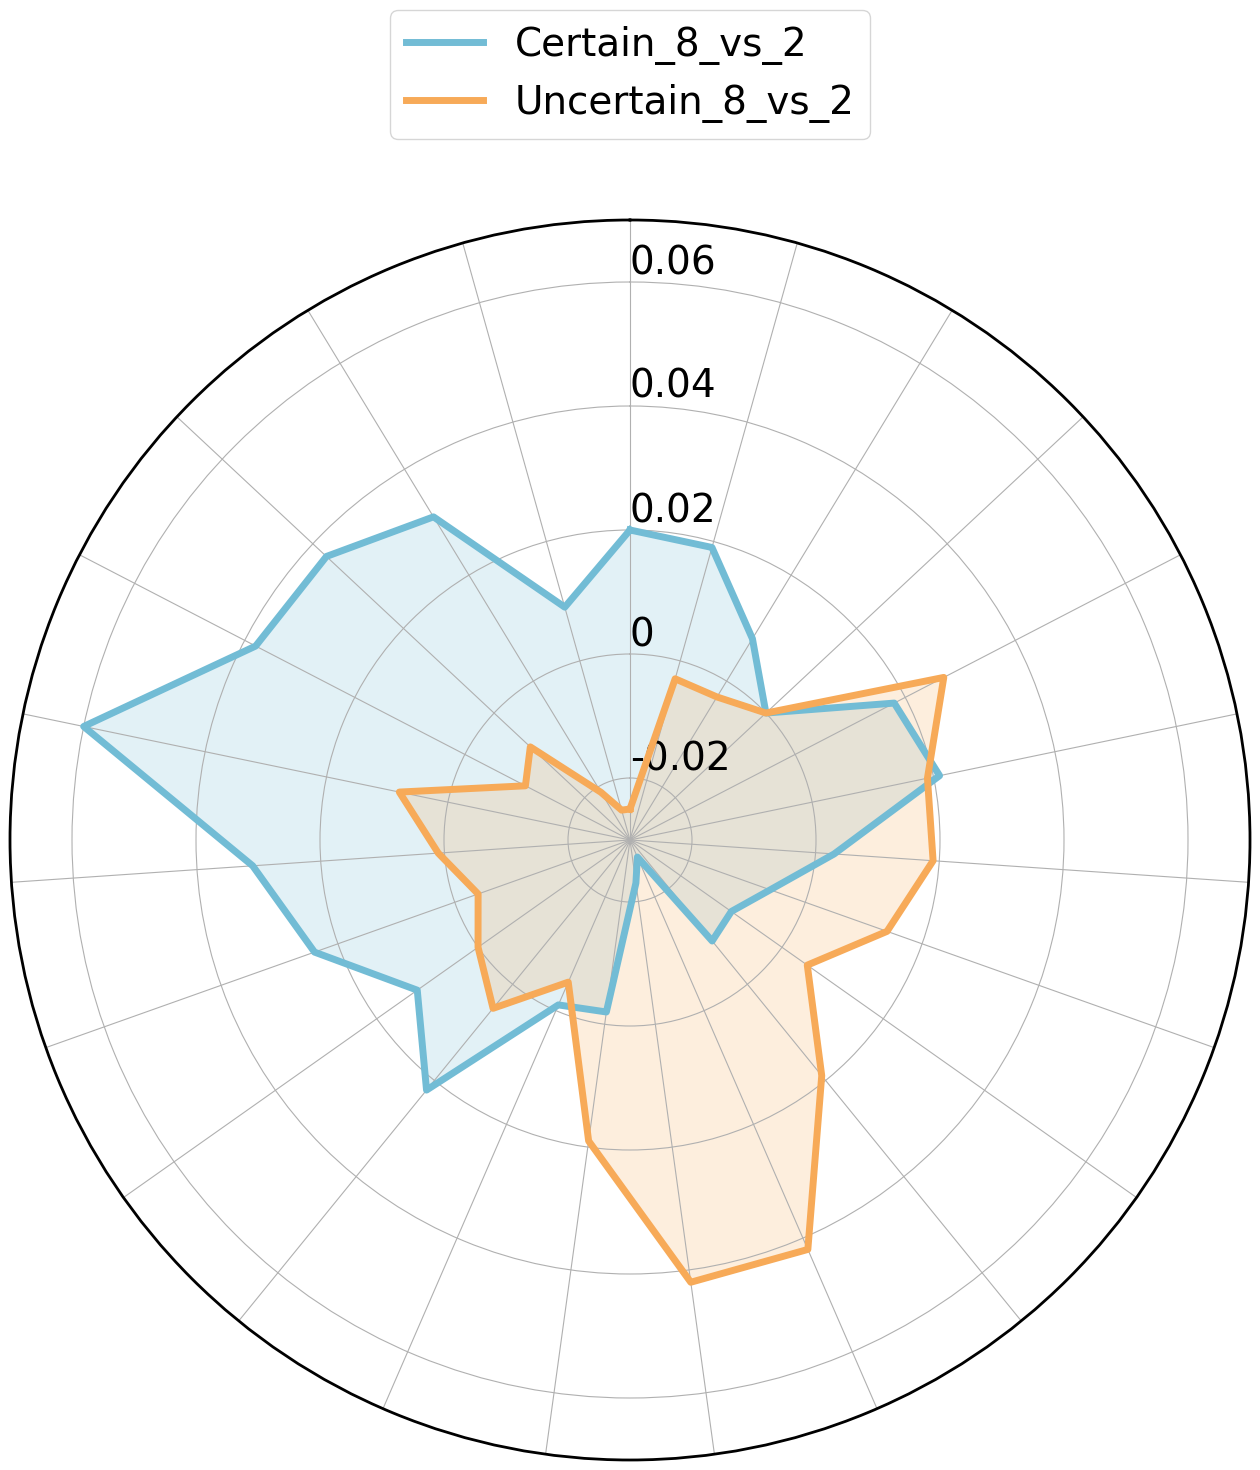

In [16]:
# ---------- 步骤1 创建背景
 
# number of variable
# 变量类别
categories = list(decode_df)[1:]
# 变量类别个数
N = len(categories)

# 设置每个点的角度值
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
 
# Initialise the spider plot
# 初始化极坐标网格
plt.figure(figsize = (16, 20))

# Create a polar subplot
ax = plt.subplot(111, polar=True)
 
# If you want the first axis to be on top:
# 设置角度偏移
ax.set_theta_offset(pi / 2)
# 设置顺时针还是逆时针，1或者-1
ax.set_theta_direction(-1)
# 设置坐标刻度到坐标轴之间的距离
ax.set_rlabel_position(600)  # 45度是示例，你可以根据需要调整这个角度
 
# Draw one axe per variable + add labels labels yet
# 设置x轴的标签
plt.xticks(angles[:-1], categories, fontsize=28)
ax.tick_params(axis='x', which='both', pad=80)

# Draw ylabels
# 画标签
ax.set_rlabel_position(0)

plt.yticks([-0.02, 0, 0.02, 0.04, 0.06], ["-0.02", "0", "0.02", "0.04", "0.06"], color="black", size=28)
plt.ylim(-0.03, 0.07)
 
# ---------- 步骤1 绘制数据
 
# 单独绘制每一组数据
# Ind1
values = decode_df.loc[0].drop('Keywords').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=5, linestyle='solid', label="Certain_8_vs_2", color='#72BCD5')
ax.fill(angles, values, color='#72BCD5', alpha=0.2)
 
# Ind2
values = decode_df.loc[1].drop('Keywords').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=5, linestyle='solid', label="Uncertain_8_vs_2", color = '#F7AA58')
ax.fill(angles, values, '#F7AA58', alpha=0.2)

# 隐藏 x 轴刻度标签和刻度线
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)

# 加粗极坐标轴线
ax.spines['polar'].set_linewidth(2)  # 极坐标系的坐标轴线

# Add legend
# 添加图例
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), fontsize=28, ncol = 1)
plt.savefig(fig_dir + 'cost_radar_241120-1.pdf', format = 'pdf', dpi = 600)
plt.savefig(fig_dir + 'cost_radar_241120-1.png', format = 'png', dpi = 600)

# Ascertain

In [25]:
decode_df = pd.read_excel(decode_data_path, sheet_name = 'Ascertain_inverse')

print(decode_df.head())
# 获取数据列名
categories = list(decode_df)[1:]
print(categories)

# 变量类别个数
N = len(categories)
print(N)

          Keywords  Punishment  Switching  Theory of mind  Salience  \
0  Risky2_vs_Risky      -0.001      0.003           0.027         0   
1  Risky8_vs_Risky      -0.038     -0.003           0.013         0   

   Calculation  Learning  Choice  Memory  Conflict  ...  Social  Emotions  \
0        0.072    -0.005   0.004   0.005    -0.007  ...   0.033     0.007   
1        0.049    -0.008   0.002   0.015     0.019  ...   0.034     0.004   

   Empathy  Anxiety   Fear  Default mode  Reward  Outcome  Prediction error  \
0    0.017   -0.005  0.004        -0.020  -0.023   -0.010            -0.004   
1    0.018   -0.008 -0.006        -0.068  -0.043   -0.025            -0.031   

   Imagine  
0   -0.008  
1   -0.023  

[2 rows x 24 columns]
['Punishment', 'Switching', 'Theory of mind', 'Salience', 'Calculation', 'Learning', 'Choice', 'Memory', 'Conflict', 'Cognitive control', 'Inhibition', 'Attention', 'Imitation', 'Social', 'Emotions', 'Empathy', 'Anxiety', 'Fear', 'Default mode', 'Reward'

In [26]:
df_value = decode_df.drop('Keywords', axis = 1)
# print(df_value)

print(df_value.max().max(), df_value.min().min())

0.099 -0.068


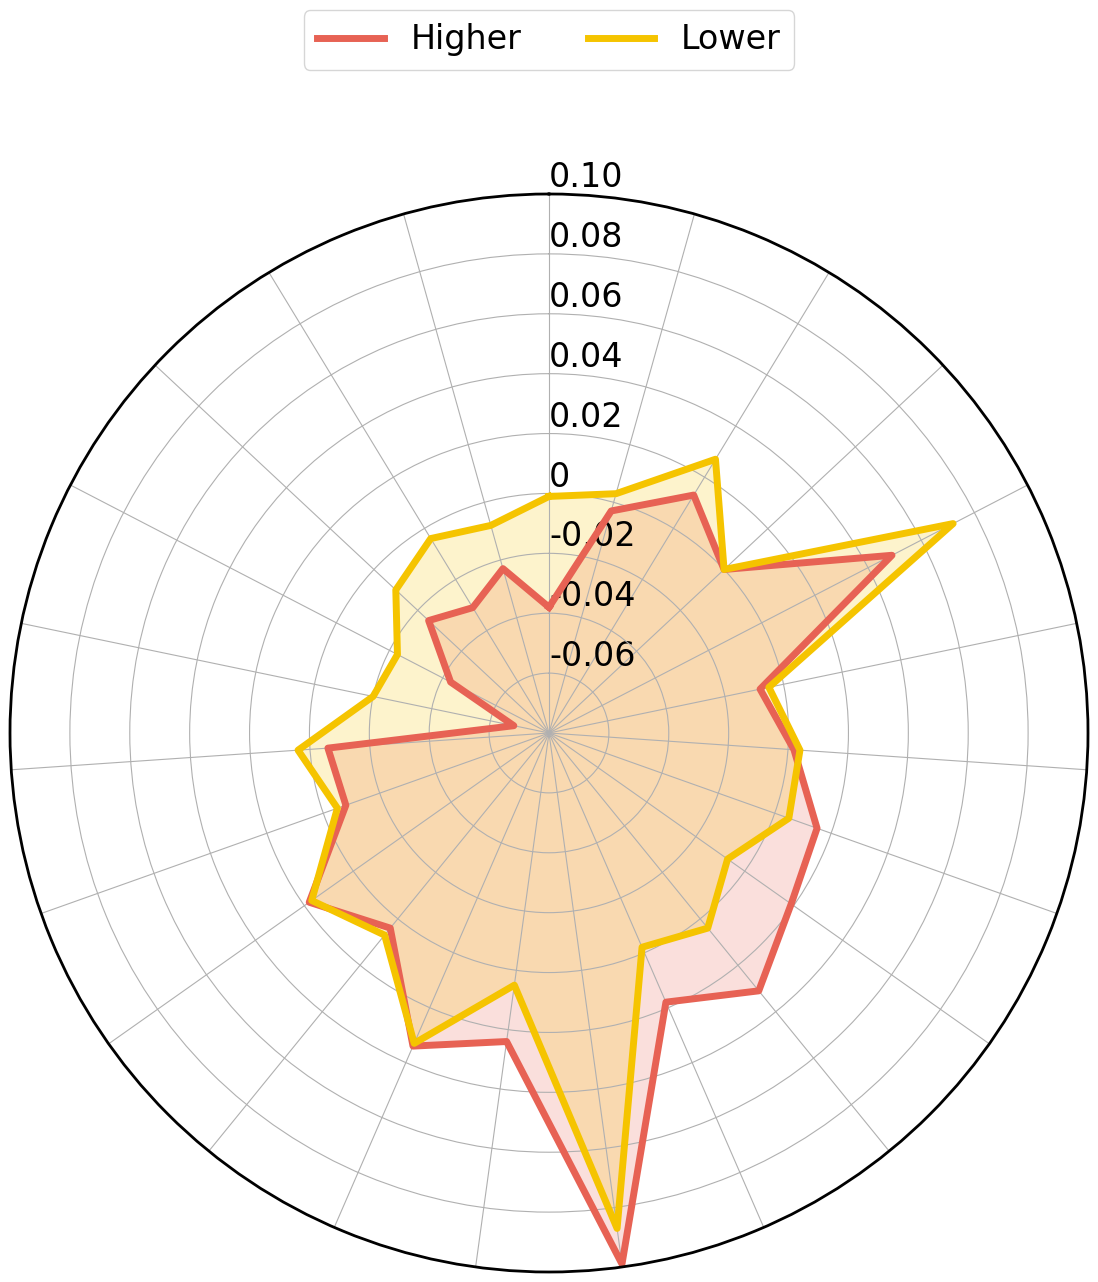

In [29]:
# ---------- 步骤1 创建背景
 
# number of variable
# 变量类别
categories = list(decode_df)[1:]
# 变量类别个数
N = len(categories)

# 设置每个点的角度值
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
 
# Initialise the spider plot
# 初始化极坐标网格
plt.figure(figsize = (16, 14))

# Create a polar subplot
ax = plt.subplot(111, polar=True)
 
# If you want the first axis to be on top:
# 设置角度偏移
ax.set_theta_offset(pi / 2)
# 设置顺时针还是逆时针，1或者-1
ax.set_theta_direction(-1)
# 设置坐标刻度到坐标轴之间的距离
ax.set_rlabel_position(600)  # 45度是示例，你可以根据需要调整这个角度
 
# Draw one axe per variable + add labels labels yet
# 设置x轴的标签
plt.xticks(angles[:-1], categories, fontsize=24)
ax.tick_params(axis='x', which='both', pad=80)

# Draw ylabels
# 画标签
ax.set_rlabel_position(0)

plt.yticks([-0.06, -0.04, -0.02, 0, 0.02, 0.04, 0.06, 0.08, 0.10], 
           ['-0.06', '-0.04', '-0.02', '0', '0.02', '0.04', '0.06', '0.08', '0.10'], color="black", size=24)
plt.ylim(-0.08, 0.1)
 
# ---------- 步骤1 绘制数据
 
# 单独绘制每一组数据

 
# Ind2
values = decode_df.loc[1].drop('Keywords').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=5, linestyle='solid', label="Higher", color="#E76254")
ax.fill(angles, values, color="#E76254", alpha=0.2)

# Ind1
values = decode_df.loc[0].drop('Keywords').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=5, linestyle='solid', label="Lower", color="#F5C400")
ax.fill(angles, values, color="#F5C400", alpha=0.2)

# 隐藏 x 轴刻度标签和刻度线
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)

# 加粗极坐标轴线
ax.spines['polar'].set_linewidth(2)  # 极坐标系的坐标轴线

# Add legend
# 添加图例
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.1), fontsize=24, ncol = 2)
plt.savefig(fig_dir + 'ascertain_radar.pdf', format = 'pdf', dpi = 600)

# Indiv differ

## Indiv differ in Risky

In [3]:
decode_df = pd.read_excel(decode_data_path, sheet_name = 'indivi_differ_Risky')

print(decode_df.head())
# 获取数据列名
categories = list(decode_df)[1:]
print(categories)

# 变量类别个数
N = len(categories)
print(N)

             Keywords  Punishment  Choice  Salience  Conflict  \
0  Asymmetry_R8_vs_R2      -0.016   0.001         0     0.014   
1   Symmetry_R8_vs_R2      -0.013   0.002         0     0.016   
2    Risky8_vs_Risky2      -0.025  -0.003         0     0.019   

   Cognitive control  Switching  Inhibition  Theory of mind  Social  ...  \
0              0.016      0.008       0.018           0.073   0.068  ...   
1              0.020     -0.007       0.002           0.008   0.004  ...   
2              0.014     -0.003       0.005           0.042   0.042  ...   

   Anxiety   Fear  Imitation  Reward  Attention  Learning  Outcome  \
0   -0.011 -0.005     -0.032  -0.012     -0.004    -0.015   -0.014   
1    0.022  0.013      0.018   0.033      0.028     0.012    0.002   
2    0.005  0.000      0.001   0.008      0.019    -0.008   -0.011   

   Prediction error  Imagine  Calculation  
0            -0.016   -0.025        0.021  
1            -0.008   -0.016        0.029  
2            -0.021  

In [4]:
df_value = decode_df.drop('Keywords', axis = 1)
# print(df_value)

print(df_value.max().max(), df_value.min().min())

0.073 -0.041


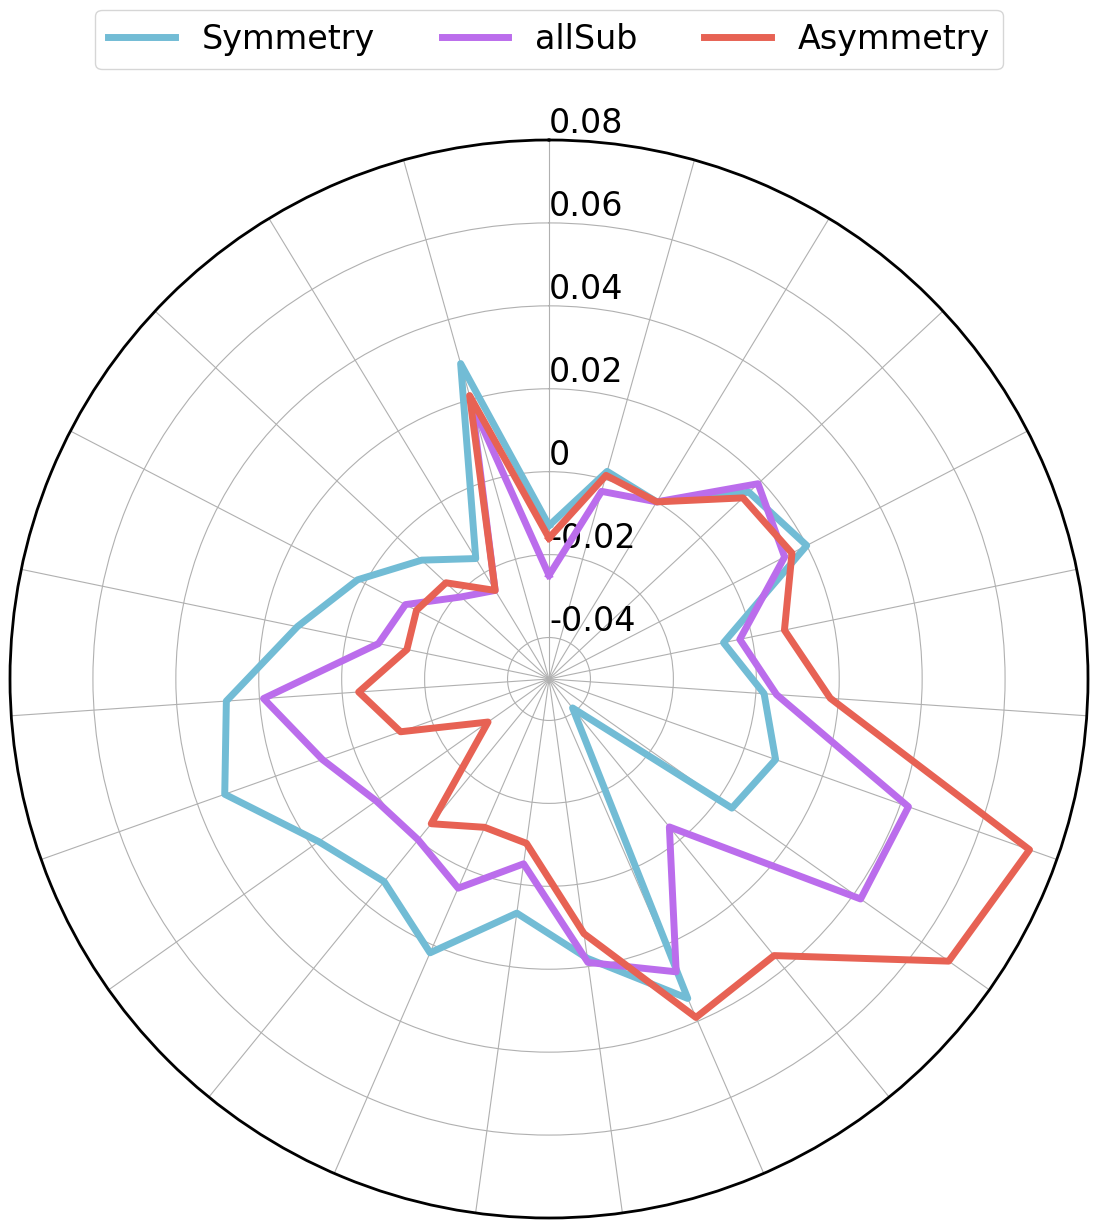

In [8]:
# ---------- 步骤1 创建背景
 
# number of variable
# 变量类别
categories = list(decode_df)[1:]
# 变量类别个数
N = len(categories)

# 设置每个点的角度值
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
 
# Initialise the spider plot
# 初始化极坐标网格
plt.figure(figsize = (16, 14))

# Create a polar subplot
ax = plt.subplot(111, polar=True)
 
# If you want the first axis to be on top:
# 设置角度偏移
ax.set_theta_offset(pi / 2)
# 设置顺时针还是逆时针，1或者-1
ax.set_theta_direction(-1)
# 设置坐标刻度到坐标轴之间的距离
ax.set_rlabel_position(600)  # 45度是示例，你可以根据需要调整这个角度
 
# Draw one axe per variable + add labels labels yet
# 设置x轴的标签
plt.xticks(angles[:-1], categories, fontsize=24)
ax.tick_params(axis='x', which='both', pad=80)

# Draw ylabels
# 画标签
ax.set_rlabel_position(0)

plt.yticks([-0.04, -0.02, 0, 0.02, 0.04, 0.06, 0.08], 
           [ '-0.04', '-0.02', '0', '0.02', '0.04', '0.06', '0.08'], color="black", size=24)
plt.ylim(-0.05, 0.08)
 
# ---------- 步骤1 绘制数据
 
# 单独绘制每一组数据

 
# Ind2
values = decode_df.loc[1].drop('Keywords').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=5, linestyle='solid', label="Symmetry", color="#72BCD5")
# ax.fill(angles, values, color="#72BCD5", alpha=0.2)

# Ind3
values = decode_df.loc[2].drop('Keywords').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=5, linestyle='solid', label="allSub", color="#bb6dec")
# ax.fill(angles, values, color="#bb6dec", alpha=0.2)

# Ind1
values = decode_df.loc[0].drop('Keywords').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=5, linestyle='solid', label="Asymmetry", color="#E76254")
# ax.fill(angles, values, color="#E76254", alpha=0.2)

# 隐藏 x 轴刻度标签和刻度线
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)

# 加粗极坐标轴线
ax.spines['polar'].set_linewidth(2)  # 极坐标系的坐标轴线

# Add legend
# 添加图例
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), fontsize=24, ncol = 3)
plt.savefig(fig_dir + 'indivi_differ_risky_radar.pdf', format = 'pdf', dpi = 600)

## Indiv differ in Certain

In [66]:
decode_df = pd.read_excel(decode_data_path, sheet_name = 'indivi_differ_Certain')

print(decode_df.head())
# 获取数据列名
categories = list(decode_df)[1:]
print(categories)

# 变量类别个数
N = len(categories)
print(N)

                     Keywords  Punishment  Choice  Memory   Fear  Imitation  \
0          Asymmetry_C8_vs_C2       0.021   0.016   0.021  0.023      0.015   
1           Symmetry_C8_vs_C2       0.008   0.016   0.013  0.002      0.004   
2        Certain8_vs_Certain2       0.020   0.019   0.018  0.012      0.031   
3  Asymmetry_C8_vs_C2_inverse      -0.021  -0.016  -0.021 -0.023     -0.015   
4   Symmetry_C8_vs_C2_inverse      -0.008  -0.016  -0.013 -0.002     -0.004   

   Imagine  Conflict  Attention  Cognitive control  ...  Default mode  Social  \
0    0.015     0.035     -0.004             -0.003  ...         0.006  -0.012   
1   -0.008    -0.034     -0.033              0.000  ...         0.033  -0.010   
2    0.009     0.003     -0.009             -0.006  ...         0.024  -0.023   
3   -0.015    -0.035      0.004              0.003  ...        -0.006   0.012   
4    0.008     0.034      0.033              0.000  ...        -0.033   0.010   

   Emotions  Empathy  Salience  Anxiet

In [67]:
df_value = decode_df.drop('Keywords', axis = 1)
# print(df_value)

print(df_value.max().max(), df_value.min().min())

0.06 -0.06


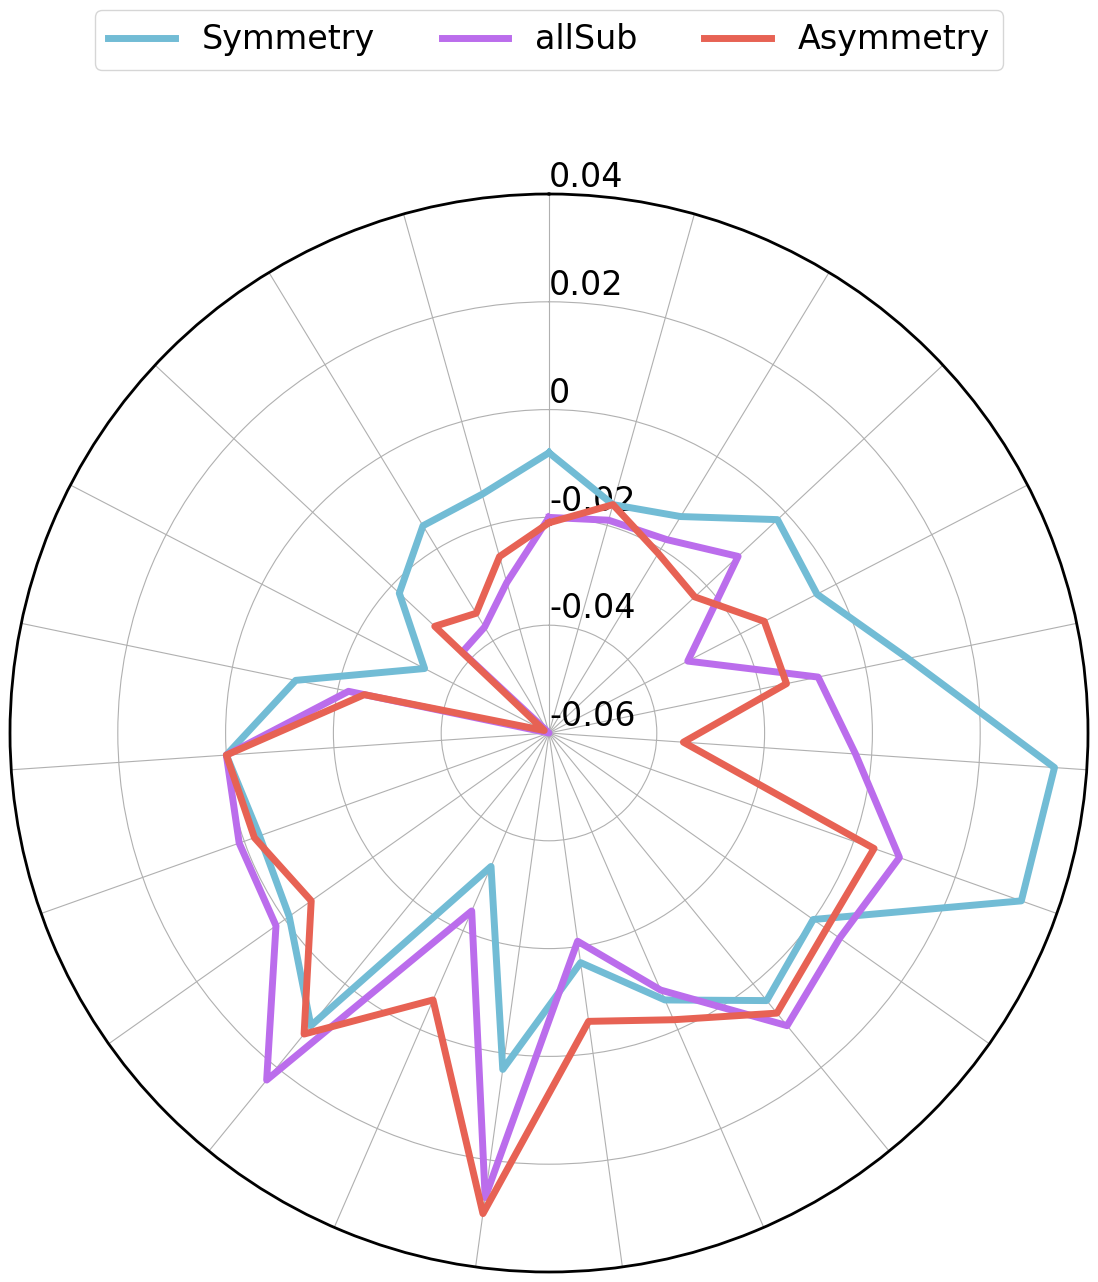

In [69]:
# ---------- 步骤1 创建背景
 
# number of variable
# 变量类别
categories = list(decode_df)[1:]
# 变量类别个数
N = len(categories)

# 设置每个点的角度值
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
 
# Initialise the spider plot
# 初始化极坐标网格
plt.figure(figsize = (16, 14))

# Create a polar subplot
ax = plt.subplot(111, polar=True)
 
# If you want the first axis to be on top:
# 设置角度偏移
ax.set_theta_offset(pi / 2)
# 设置顺时针还是逆时针，1或者-1
ax.set_theta_direction(-1)
# 设置坐标刻度到坐标轴之间的距离
ax.set_rlabel_position(600)  # 45度是示例，你可以根据需要调整这个角度
 
# Draw one axe per variable + add labels labels yet
# 设置x轴的标签
plt.xticks(angles[:-1], categories, fontsize=24)
ax.tick_params(axis='x', which='both', pad=80)

# Draw ylabels
# 画标签
ax.set_rlabel_position(0)

plt.yticks([-0.06, -0.04, -0.02, 0, 0.02, 0.04], 
           [ '-0.06', '-0.04', '-0.02', '0', '0.02', '0.04'], color="black", size=24)
plt.ylim(-0.06, 0.04)
 
# ---------- 步骤1 绘制数据
 
# 单独绘制每一组数据

 
# Ind2
values = decode_df.loc[4].drop('Keywords').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=5, linestyle='solid', label="Symmetry", color="#72BCD5")
# ax.fill(angles, values, color="#72BCD5", alpha=0.2)

# Ind3
values = decode_df.loc[5].drop('Keywords').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=5, linestyle='solid', label="allSub", color="#bb6dec")
# ax.fill(angles, values, color="#bb6dec", alpha=0.2)

# Ind1
values = decode_df.loc[3].drop('Keywords').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=5, linestyle='solid', label="Asymmetry", color="#E76254")
# ax.fill(angles, values, color="#E76254", alpha=0.2)

# 隐藏 x 轴刻度标签和刻度线
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)

# 加粗极坐标轴线
ax.spines['polar'].set_linewidth(2)  # 极坐标系的坐标轴线

# Add legend
# 添加图例
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.1), fontsize=24, ncol = 3)
plt.savefig(fig_dir + 'indivi_differ_certain_radar.png', format = 'pdf', dpi = 600)